In [ ]:
# Colab reproducibility — uncomment to clone the repo and enter this folder:
# !git clone https://github.com/JuliettKhar/mlops-zoomcamp-exercises.git
# %cd mlops-zoomcamp-exercises/01-intro

In [33]:
import pandas as pd

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
from sklearn.feature_extraction import DictVectorizer

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

In [37]:
import pickle

In [38]:
filename = 'https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2026-01.parquet'

In [39]:
df = pd.read_parquet(filename)

In [40]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.7,...,1.5,7.5,0.0,NaN,1.0,45.20,1.0,1.0,2.75,0.75
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.0,...,0.0,10.2,0.0,NaN,1.0,61.20,1.0,2.0,0.00,0.00
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.5,...,1.5,2.0,0.0,NaN,1.0,46.00,1.0,1.0,0.00,0.00
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.8,...,1.5,0.0,0.0,NaN,1.0,25.05,2.0,1.0,2.75,0.00
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.1,...,0.5,0.0,0.0,NaN,1.0,21.60,2.0,1.0,0.00,0.00


In [41]:
df.dtypes

VendorID                          int32
lpep_pickup_datetime     datetime64[us]
lpep_dropoff_datetime    datetime64[us]
store_and_fwd_flag               object
RatecodeID                      float64
PULocationID                      int32
DOLocationID                      int32
passenger_count                 float64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
ehail_fee                       float64
improvement_surcharge           float64
total_amount                    float64
payment_type                    float64
trip_type                       float64
congestion_surcharge            float64
cbd_congestion_fee              float64
dtype: object

In [42]:
df.trip_type.value_counts()

trip_type
1.0    33234
2.0     1623
Name: count, dtype: int64

In [43]:
df_filtered = df[df.trip_type == 2]
df_filtered.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.0,...,0.0,10.2,0.0,NaN,1.0,61.2,1.0,2.0,0.00,0.00
8,2,2026-01-01 00:53:05,2026-01-01 00:56:27,N,5.0,92,92,1.0,0.51,15.0,...,0.0,0.0,0.0,NaN,1.0,16.0,1.0,2.0,0.00,0.00
15,2,2026-01-01 00:30:37,2026-01-01 00:30:40,N,5.0,92,92,1.0,0.00,30.0,...,0.0,0.0,0.0,NaN,1.0,31.0,1.0,2.0,0.00,0.00
20,2,2025-12-31 22:00:16,2025-12-31 22:00:22,N,5.0,70,70,2.0,0.00,24.0,...,0.0,0.0,0.0,NaN,1.0,25.0,1.0,2.0,0.00,0.00
37,2,2026-01-01 00:49:19,2026-01-01 01:48:30,N,5.0,66,48,1.0,5.76,80.0,...,0.0,0.0,0.0,NaN,1.0,84.5,1.0,2.0,2.75,0.75


In [44]:
df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)

In [45]:
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

In [46]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,duration
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.7,...,7.5,0.0,NaN,1.0,45.20,1.0,1.0,2.75,0.75,27.300000
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.0,...,10.2,0.0,NaN,1.0,61.20,1.0,2.0,0.00,0.00,48.383333
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.5,...,2.0,0.0,NaN,1.0,46.00,1.0,1.0,0.00,0.00,21.300000
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.8,...,0.0,0.0,NaN,1.0,25.05,2.0,1.0,2.75,0.00,16.200000
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.1,...,0.0,0.0,NaN,1.0,21.60,2.0,1.0,0.00,0.00,18.600000


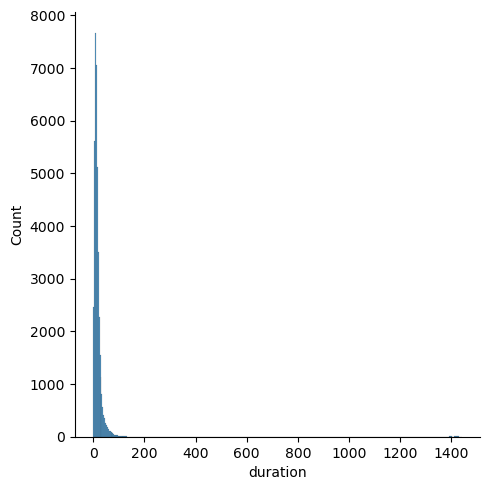

In [47]:
sns.displot(df.duration)

In [48]:
df.duration.describe(percentiles=[0.95, 0.98, 0.99])

count    40272.000000
mean        20.075434
std         69.852105
min          0.000000
50%         12.883333
95%         44.016667
98%         64.286000
99%         82.886500
max       1439.800000
Name: duration, dtype: float64

In [49]:
df = df[((df.duration >= 0) & (df.duration <= 120))]

In [50]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,duration
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.7,...,7.5,0.0,NaN,1.0,45.20,1.0,1.0,2.75,0.75,27.300000
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.0,...,10.2,0.0,NaN,1.0,61.20,1.0,2.0,0.00,0.00,48.383333
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.5,...,2.0,0.0,NaN,1.0,46.00,1.0,1.0,0.00,0.00,21.300000
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.8,...,0.0,0.0,NaN,1.0,25.05,2.0,1.0,2.75,0.00,16.200000
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.1,...,0.0,0.0,NaN,1.0,21.60,2.0,1.0,0.00,0.00,18.600000


In [51]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

In [52]:
df[categorical] = df[categorical].astype(str)

In [53]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

mean_squared_error(y_train, y_pred)

115.84283658264883

/var/folders/gk/87pgnywd0yj8v_zr8sbrmdd40000gn/T/ipykernel_80943/1505421196.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/var/folders/gk/87pgnywd0yj8v_zr8sbrmdd40000gn/T/ipykernel_80943/1505421196.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, lab

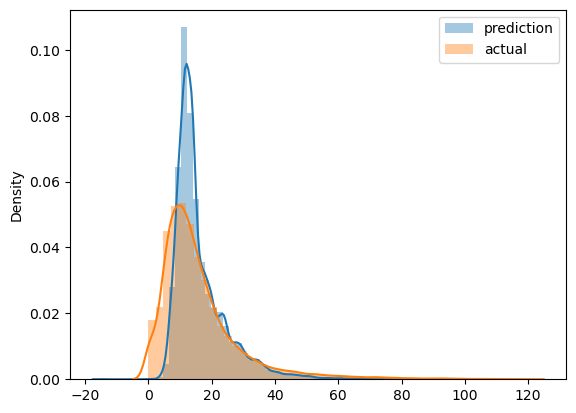

In [54]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')
plt.legend()

In [55]:
def read_dataframe(filename): 
    df = pd.read_parquet(filename)
    df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
    df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    
    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)
    
    df = df[((df.duration >= 0) & (df.duration <= 120))]
    
    categorical = ['PULocationID', 'DOLocationID']
    # numerical = ['trip_distance']
    df[categorical] = df[categorical].astype(str)

    return df

In [56]:
df_train = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2026-01.parquet')
df_val = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2026-02.parquet')

In [57]:
df_train ['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID'] 
df_val ['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID'] 

In [58]:
len(df_train), len(df_val)

(40095, 37192)

In [59]:
categorical = ['PU_DO'] 
    # ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()
# X_train = dv.fit_transform(train_dicts)
train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts =  df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [60]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [61]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

mean_squared_error(y_val, y_pred)

91.21563858633118

In [62]:
lr = Lasso(alpha=0.001)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

mean_squared_error(y_val, y_pred)

105.84287186096834

In [63]:
lr = Ridge()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

mean_squared_error(y_val, y_pred)

90.94654468627954

In [64]:
import os
os.makedirs('../models', exist_ok=True)
with open('../models/lin_reg.bin', 'wb') as f_out:
          pickle.dump((dv, lr), f_out)